In [1]:
import torch
import os

device = torch.device('cpu')
batch_size = 32
embedding_dim = 32
gin_hidden_channel = 32
gin_layers=2
gru_hidden_channel=64

num_nodes=60

learning_rate = 0.001
scheduler_patience = 5
early_stopping_patience = 10


In [2]:
cur_dir = os.getcwd()
root = os.path.join(cur_dir, 'data_tensor_cache')
model_path = os.path.join(cur_dir, 'checkpoints', 'gingru', 'real', 'best_gingru_epoch_4_loss_0.3886.pth')
mi_dict_path = os.path.join(root, 'data', 'mi_dict_static.pickle')

In [3]:
from teds_tensor_dataset import TEDSTensorDataset
dataset = TEDSTensorDataset(root)

col_list, col_dims, ad_col_index, dis_col_index = dataset.col_info

from utils.processing_utils import train_test_split_customed
train_loader, val_loader, test_loader = train_test_split_customed(dataset, batch_size)

/opt/miniconda3/envs/pyg_2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


저장되어 있는 전처리된 데이터가 있습니다. 해당 데이터를 불러오는 중..
불러오기 완료
Train Set Size: 975896
Valid Set Size: 209119
Test Set Size: 209123


In [4]:
from models.gingru_for_explain import GinGruForExplain2
from models.gin_gru import GinGru

model = GinGru(
    batch_size=batch_size,
    col_list=col_list,
    col_dims=col_dims,
    ad_col_index=ad_col_index,
    dis_col_index=dis_col_index,
    embedding_dim=embedding_dim,
    gin_hidden_channel=gin_hidden_channel,
    train_eps=True,
    gin_layers=gin_layers,
    gru_hidden_channel=gru_hidden_channel
)

In [5]:
def load_checkpoint(model, optimizer, scheduler, filename, map_location=None):
    checkpoint = torch.load(filename, map_location=map_location)

    # --- Load states ---
    model.load_state_dict(checkpoint['model_state_dict'], strict=False)
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'], strict=False)
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'], strict=False)
    start_epoch = checkpoint['epoch'] + 1
    best_loss = checkpoint['best_loss']

    return start_epoch, best_loss

In [6]:
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
from utils.early_stopper import EarlyStopper

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, "min", patience=scheduler_patience)
early_stopper = EarlyStopper(patience=early_stopping_patience)

load_checkpoint(model, optimizer, scheduler, model_path)
model = model.to(device)
model = model.eval()

RuntimeError: Error(s) in loading state_dict for GinGru:
	size mismatch for entity_embedding_layer.embedding_layer.weight: copying a param with shape torch.Size([1143, 64]) from checkpoint, the shape in current model is torch.Size([1143, 32]).
	size mismatch for gin_layers.0.nn.0.weight: copying a param with shape torch.Size([64, 64]) from checkpoint, the shape in current model is torch.Size([32, 32]).
	size mismatch for gin_layers.0.nn.0.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for gin_layers.0.nn.1.weight: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for gin_layers.0.nn.1.bias: copying a param with shape torch.Size([64]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for gin_layers.1.nn.0.weight: copying a param with shape torch.Size([64, 64]) from checkpoint, the shape in current model

In [ ]:
from utils.processing_utils import mi_edge_index_batched

edge_index = mi_edge_index_batched(batch_size,
                                   num_nodes=num_nodes,
                                   mi_dict_path=mi_dict_path)

edge_index = edge_index.to(device)

result_list = []
for batch in test_loader:
    x_batch, y_batch, los_batch = batch
    logits = model(x_batch, los_batch, edge_index, device)
    probs = torch.sigmoid(logits)
    result_list.append(probs)
    print(probs)

TypeError: GinGruForExplain2.forward() takes 3 positional arguments but 5 were given

In [ ]:
probs_flat = torch.cat(result_list)

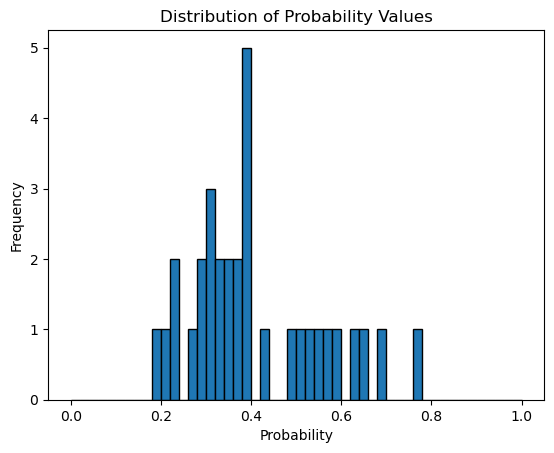

In [ ]:
import matplotlib.pyplot as plt

# probs: 모델의 출력에 sigmoid를 적용한 확률 값들 (PyTorch Tensor)
probs_flat = probs.detach().cpu().numpy().flatten()

plt.hist(probs_flat, bins=50, range=(0, 1), edgecolor='black')
plt.title('Distribution of Probability Values')
plt.xlabel('Probability')
plt.ylabel('Frequency')
plt.show()